# **Bank Telemarketing Dataset -- Client EDA Approach**

In [1]:
## Import commonly used libraries
import pandas as pd 
import numpy as np  
import sidetable
import sklearn
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob
from itertools import combinations

## Display Setting

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings('ignore')

In [3]:
file = []
data_path = Path.cwd().parent.joinpath("data", "raw")
for f in data_path.glob("*"):
    file.append(f.name)

print(file)

['.gitkeep', 'bank-additional-full.csv', 'bank-additional-names.txt', 'bank-full.csv', 'info.txt']


In [4]:
tele_df = pd.read_csv(data_path.joinpath("bank-additional-full.csv"), sep=';')
tele_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
tele_df.shape

(41188, 21)

In [6]:
# Remove whitespaces, ., spaces and lowercase column names
tele_df.columns = tele_df.columns.str.strip().str.replace(".", " ").str.replace(" ", "_").str.lower()
tele_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [7]:
tele_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [8]:
# Check Missing values
import sidetable
miss_df = tele_df.stb.missing()
miss_df.query("percent > 0")

,missing,total,percent


**No Missing Value in give dataset for numeric variables, will explore this.**

**Missing Attribute Values for Categorical Variables:** There are several missing values in some categorical attributes, all coded with the "unknown" label. These missing values can be treated as a possible class label or using deletion or imputation techniques.


**Bank Client Data Description:**

- **age**: Age of the client (numeric)
- **job**: Type of job (categorical: 'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown')
- **marital**: Marital status (categorical: 'divorced', 'married', 'single', 'unknown')
- **education**: Level of education (categorical: 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown')
- **default**: Whether the client has credit in default (binary: 'no', 'yes', 'unknown')
- **housing**: Whether the client has a housing loan (binary: 'no', 'yes', 'unknown')
- **loan**: Whether the client has a personal loan (binary: 'no', 'yes', 'unknown')


## **Formatting and Consistency Check**

In [9]:
dtype_df = pd.DataFrame({
    'dtype': tele_df.dtypes,
    'nunique': tele_df.nunique(),
    'unique' : [tele_df[col].unique() for col in tele_df.columns]
}, index=tele_df.columns)
dtype_df

,dtype,nunique,unique
age,int64,78,"[56, 57, 37, 40, 45, 59, 41, 24, 25, 29, 35, 5..."
job,object,12,"[housemaid, services, admin., blue-collar, tec..."
marital,object,4,"[married, single, divorced, unknown]"
education,object,8,"[basic.4y, high.school, basic.6y, basic.9y, pr..."
default,object,3,"[no, unknown, yes]"
housing,object,3,"[no, yes, unknown]"
loan,object,3,"[no, yes, unknown]"
contact,object,2,"[telephone, cellular]"
month,object,10,"[may, jun, jul, aug, oct, nov, dec, mar, apr, ..."
day_of_week,object,5,"[mon, tue, wed, thu, fri]"


# **Exploratory Data Analysis ---- bank client attributes**

**Target Variable**

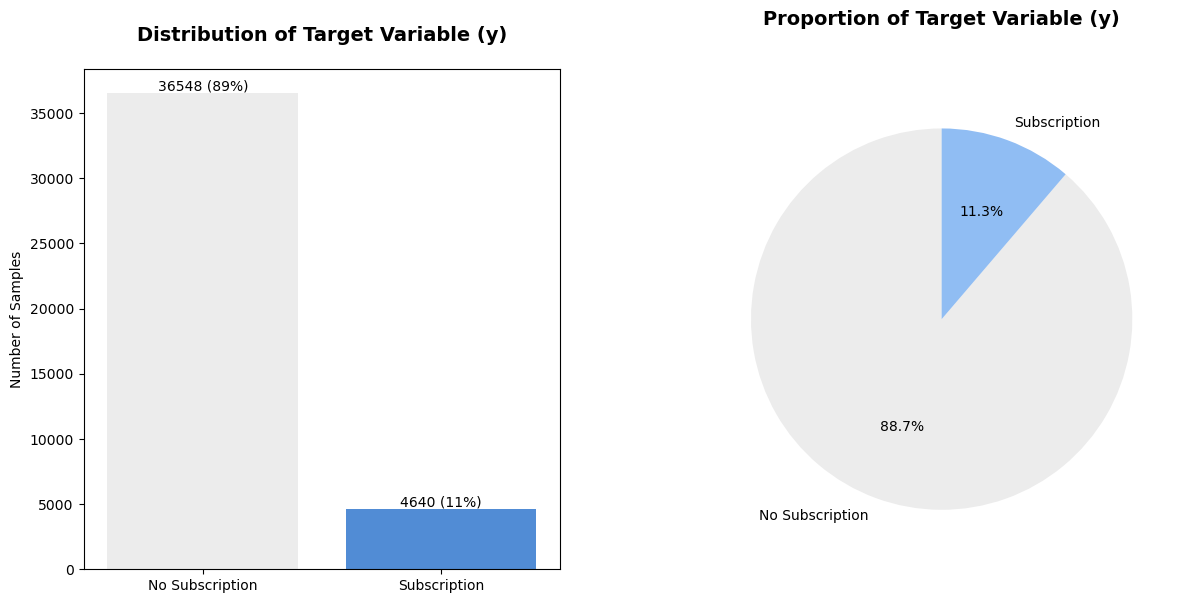

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# Countplot for target variable
sns.countplot(
    data=tele_df, x='y', 
    order=tele_df['y'].value_counts().index, 
    palette = ['#ececec', '#3B8AEB90'],
    ax=ax[0])

ax[0].set_title('Distribution of Target Variable (y)', fontsize=14, fontweight='bold', y=1.04)
ax[0].set_xlabel('')
ax[0].set_ylabel('Number of Samples')
ax[0].set_xticks([0, 1], labels = ['No Subscription', 'Subscription'], rotation=0)

# Add percentage labels on bars
for i, v in enumerate(tele_df['y'].value_counts()):
    percentage = 100 * v / len(tele_df)
    ax[0].text(i, v + 200, f"{v} ({percentage:.0f}%)", ha='center', fontsize=10)

# Pie chart for target variable
tele_df['y'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    colors = ['#ececec', "#3B8AEB90"], 
    startangle=90, labels = ['No Subscription', 'Subscription'],
    ax=ax[1])

ax[1].set_ylabel('')
ax[1].set_title('Proportion of Target Variable (y)', fontsize=14, fontweight='bold', y=1.10)

# Add layout adjustments
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

**Data is highly imbalanced, with a significant majority of customers not subscribing to the term deposit. This imbalance will need to be addressed in the modeling phase, possibly through techniques such as resampling or using algorithms that can handle class imbalance effectively.**

In [11]:
# Make y binary in next step:
tele_df['y_binary'] = tele_df['y'].map({'yes': 1, 'no':0})

### **Dimension Analysis**

In [12]:
tele_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'y_binary'],
      dtype='object')

In [51]:
## dimensions to be focus for eda
cols = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'y', 'y_binary']
client_df = tele_df[cols]

**Metric : Conversion Rate**

How to calculate : Conversion rate compute by total number of term deposit subscribers/ Total number of contact.

**Dimension : `job`**

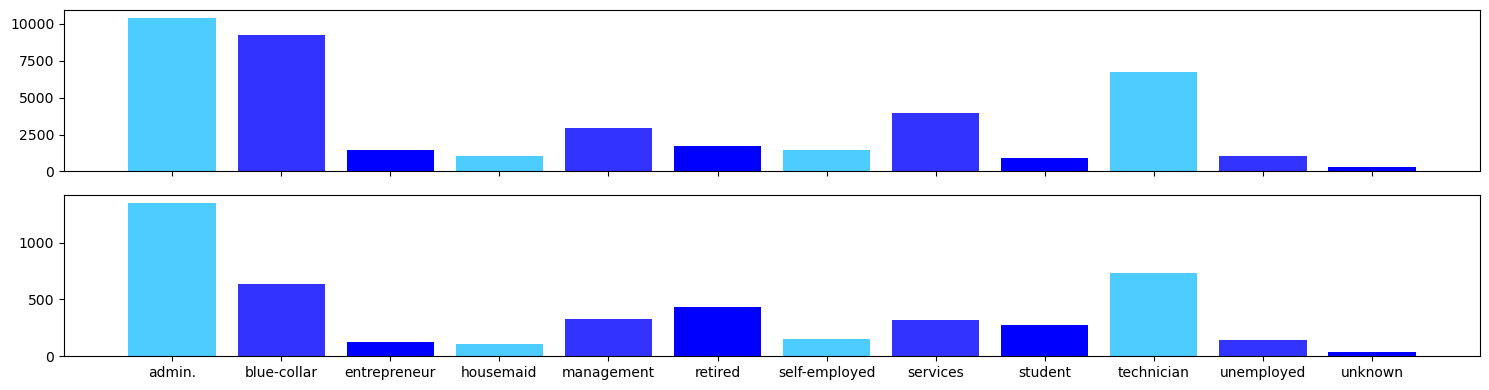

In [69]:
count_df = client_df.groupby(['job'])['y'].value_counts().unstack().assign(total=lambda x: x.sum(axis='columns'))
count_df
fig, ax = plt.subplots(2, 1, figsize=(15, 4), sharex=True)
color = [(0.3, 0.8, 1), (0.2, 0.2, 1), '#0000ff']
x_pos = range(len(count_df.index))
ax[0].bar(x_pos, count_df['total'], color =color)

ax[1].bar(x_pos, count_df['yes'], color=color)
ax[1].set_xticks(ticks=x_pos, labels=count_df.index)
plt.tight_layout();

In [74]:
# Univariate analysis function for categorical variables with bar plots
def univariate_analysis_categorical_var(df, categorical_var, display_name):
    """Compute total count of customers contacted and percentage of customers who subscribed to a term deposit."""
    # Count of campaign for each category
    total_counts = df.groupby([categorical_var])['y'].value_counts().unstack().fillna(0)   
    total_counts['total'] = total_counts.sum(axis='columns')
    total_counts = total_counts.sort_values(by='total', ascending=False)
    total_counts['conversion_rate'] = (total_counts['yes'] / total_counts['total']).round(2)

    fig, ax = plt.subplots(2, 1, sharex=True,figsize=(15, 8), dpi=100)
    #colors = plt.cm.Blues_r(np.arange(0.3, 0.9, len(total_counts.index))) 
    colors = [(0.3, 0.8, 1), (0.6, 0.6, 1), '#0000FF']
    # plot for total campaigns
    x_pos = range(len(total_counts.index))
    ax[0].bar(x_pos, total_counts['total'], color=colors)
    ax[0].set_xticks(x_pos)
    ax[0].set_xticklabels(total_counts.index)
    ax[0].set_title(display_name + ' Distribution', fontsize=14, fontweight='bold', y=1.04)
    for i, v in enumerate(total_counts['total']):
        ax[0].text(i, v + 200, f"{int(v)} ({(v/(total_counts['total'].sum(axis=0))):.0%})", ha='center', fontsize=10)

    # plot for successful subscriptions
    ax[1].bar(x_pos, total_counts['conversion_rate'], color=colors)
    ax[1].set_xticks(x_pos)
    ax[1].set_xticklabels(total_counts.index)
    #ax[1].set_yticklabels([f"{y/ax[1].get_ylim()[1]:.2f}" for y in ax[1].get_yticks()])
    ax[1].set_title(display_name +" " + 'YES-proportion', fontsize=14, fontweight='bold', y=1.04)
    for i, v in enumerate(total_counts['conversion_rate']):
        ax[1].text(i, v , f"({total_counts['conversion_rate'].iloc[i]:.2f})", ha='center', fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)
    plt.show()

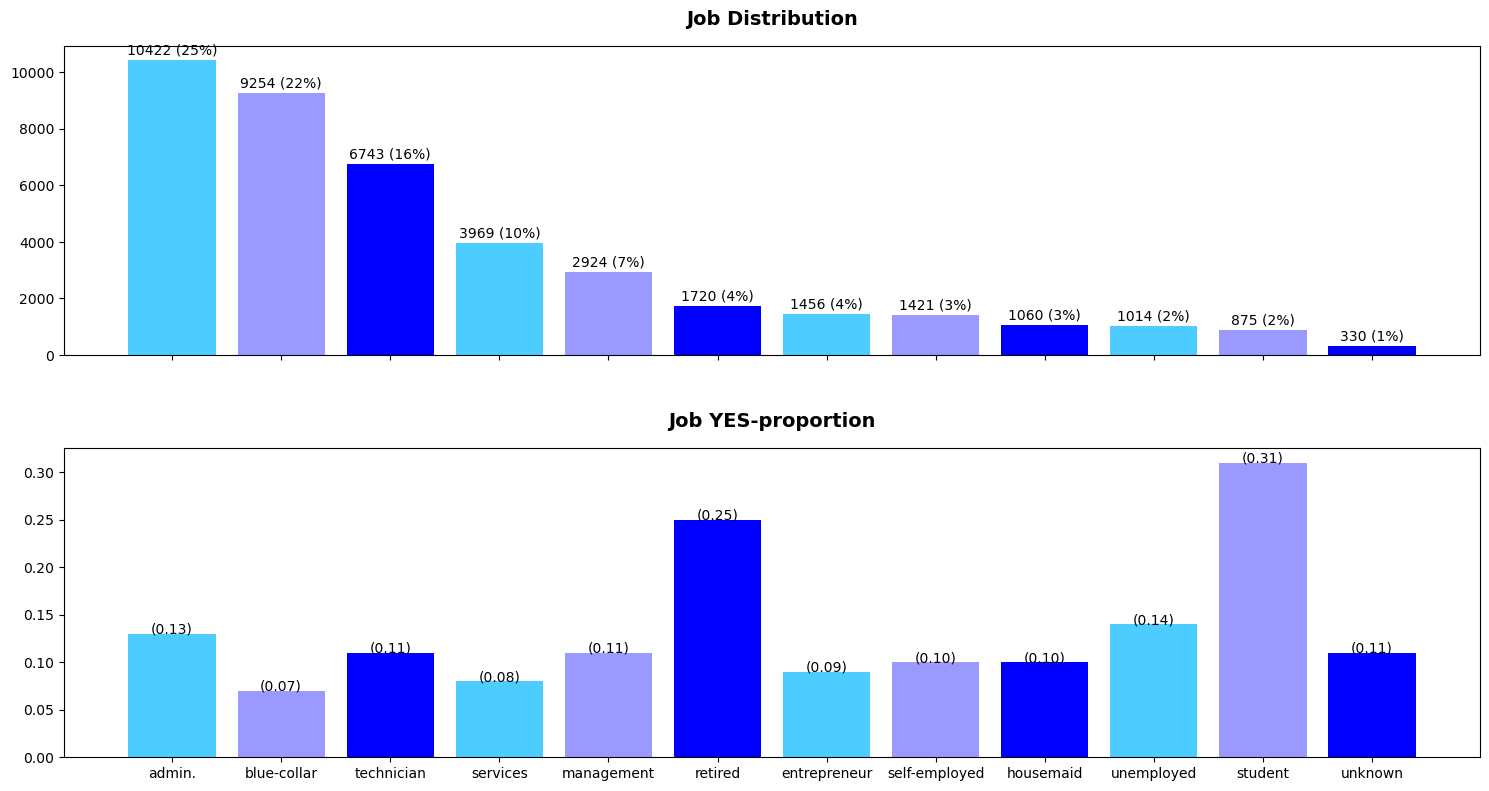

In [75]:
univariate_analysis_categorical_var(tele_df, 'job', 'Job')

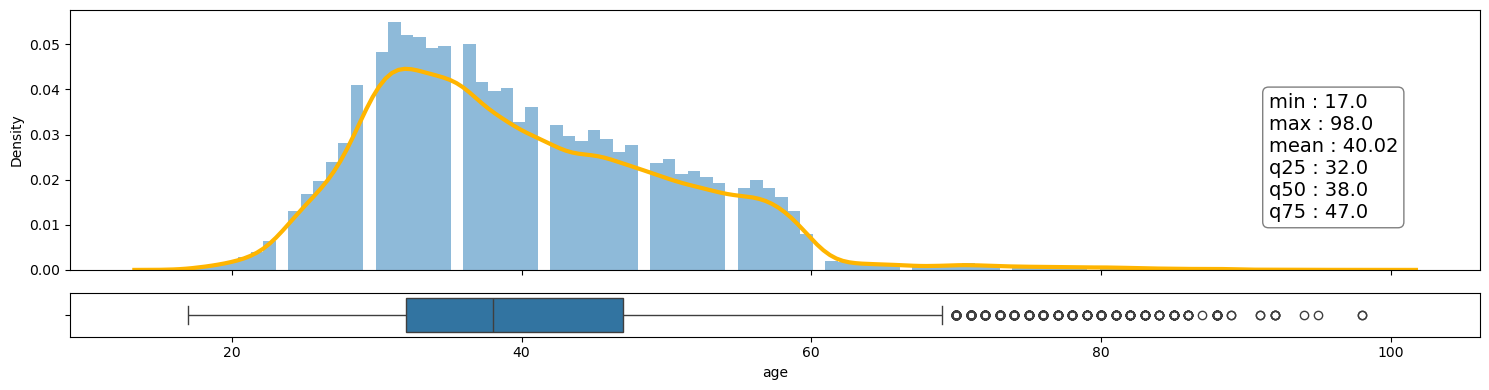

In [49]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(15, 4), gridspec_kw={'height_ratios':[3, 0.5]})
sns.histplot(client_df['age'], stat='density', kde=True, lw=0, ax=ax[0]);
sns.kdeplot(client_df['age'], color='#ffb500', lw=3, ax=ax[0]);

# Add text for features descriptive statistics
_, mean_val, _, min_val, q25, median, q75, max_val = np.round(client_df['age'].describe(), 2)
features_stats_text = f"min : {min_val}\nmax : {max_val}\nmean : {mean_val}\nq25 : {q25}\nq50 : {median}\nq75 : {q75}"
box = dict(boxstyle='round', alpha=0.5, fc='white', ec='k')
x_coor, y_coor = np.quantile(ax[0].get_xlim(), 0.85), np.quantile(ax[0].get_ylim(), 0.2)

ax[0].text(x_coor, y_coor, features_stats_text, fontsize=14, color='k', bbox=box);

sns.boxplot(data = client_df, x ='age', ax=ax[1]);
plt.tight_layout();